In [ ]:
!pip install torch gymnasium[atari,accept-rom-license] numpy matplotlib


In [ ]:
!pip install opencv-python

## OMA ALGORITMI



## Setting up + DQN class + ReplayBuffer class

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing
from gymnasium.wrappers import FrameStackObservation
import torch
import math
import matplotlib
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import numpy as np
import cv2
import ale_py
from collections import deque, namedtuple
from itertools import count
from google.colab import files

# mount drive for saving the net as *.pth
from google.colab import drive
drive.mount('/content/drive')

# setting up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# GPU if possible
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print("Device: ", device)

#SEED = 13
#random.seed(SEED)
#np.random.seed(SEED)
#torch.manual_seed(SEED)



# DQN class
class DQN(nn.Module):
  def __init__(self, num_actions):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(4, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(7*7*64, 512)
        self.fc2 = nn.Linear(512, num_actions)

  def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# Transition-tuple
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

# Replay memory
class ReplayBuffer:
  def __init__(self, capacity):
    self.buffer = deque(maxlen=capacity)

  # adding to memory
  def push(self, *args):
    self.buffer.append((Transition(*args)))

  # random sample from memory
  def sample(self, batch_size):
    return random.sample(self.buffer, batch_size)

  def __len__(self):
    return len(self.buffer)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device:  cuda


## Constants / hyper-parameters

In [ ]:


BATCH_SIZE = 128
GAMMA = 0.99
EPSILON_START = 0.95    # DECAYING EPSILON 0.95 -> 0.05 WITH 2500 STEPS
EPSILON_END = 0.05
EPSILON_DECAY = 100000
NUM_EPISODES = 5000      # TOTAL EPISODES
#TAU = 0.0005             # Soft update rate
TARGET_UPDATE = 1000     # TARGET NETWORK UPDATE RATE
MIN_REPLAY_SIZE = 1000  # REPLAY MEMORY GETS UPDATED ONLY AFTER THERE'S 1000 STEPS TO PUSH

## Functions

In [ ]:

# global variable
steps_taken = 0



# Selecting random action with probability epsilon,
# else selecting the action with best Q-value

def select_action(state):
  global steps_taken


  random_coin_flip = random.random()
  epsilon_treshold = EPSILON_END + (EPSILON_START - EPSILON_END) * \
    math.exp(-1. * steps_taken / EPSILON_DECAY)

  steps_taken += 1

  if random_coin_flip > epsilon_treshold:
    with torch.no_grad():
      action = q(state).max(1).indices.view(1, 1)
  else:
    action = env.action_space.sample()
    action = torch.tensor([[action]], device=device, dtype=torch.long)

  return action



# Frame preprocessing for faster handling
# NOT NEEDED IF ATARI PREPROCESSING AVAILABLE
def preprocess(state):
    # Convert to grayscale
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    # Resize
    frame = cv2.resize(frame, (84, 84))
    # Normalize pixel values
    frame = frame / 255.0
    return frame

episode_durations = []

# Plot games by duration
# !!! I followed the trivial plotting function from the official PyTorch reinforcement
# learning tutorial. !!!
def plot_durations(show_result=False):
  plt.figure(1)
  durations_t = torch.tensor(episode_durations, dtype=torch.float)
  if show_result:
    plt.title('Result')
  else:
    plt.clf()
    plt.title('Training...')
  plt.xlabel('Episode')
  plt.ylabel('Duration')
  plt.plot(durations_t.numpy())

  # plot average after 100 steps
  if len(durations_t) >= 100:
    means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
    means = torch.cat((torch.zeros(99), means))
    plt.plot(means.numpy())

  plt.pause(0.001)
  if is_ipython:
    if not show_result:
      display.display(plt.gcf())
      display.clear_output(wait=True)
    else:
      display.display(plt.gcf())



episode_rewards = []



# Plot games by rewards
# !!! I used ChatGPT to help create this trivial function !!!
def plot_rewards(show_result=False, window=50):
    plt.figure(1)
    plt.clf()

    rewards = episode_rewards
    plt.title('Training - Episode Rewards' if not show_result else 'Final Result')
    plt.xlabel('Episode')
    plt.ylabel('Reward')

    # Raw rewards
    plt.plot(rewards, label="Reward")

    # Moving average of 50 episodes
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(rewards)), moving_avg, label=f'{window}-episode MA')

    plt.legend()
    plt.grid(alpha=0.3)

    # single live plot
    display.clear_output(wait=True)
    display.display(plt.gcf())



# Optimization function
# !!! Hints taken from PyTorch reinforcement learning tutorial !!!
# I couldn't figure out this part very well so ended up following most
# of their code.

def optimize_model():
    # check that there's enough data in the memory
    if len(replay_memory) < BATCH_SIZE:
        return

    # random sample from replay memory
    transitions = replay_memory.sample(BATCH_SIZE)

    # transposing batch
    batch = Transition(*zip(*transitions))

    # mask of non-final elements (such where simulation hasn't ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # compute the Q(s,a) values for the batch with the Q-net
    state_action_values = q(state_batch).gather(1, action_batch)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    # compute expected values with target net
    with torch.no_grad():
        next_state_values[non_final_mask] = target(non_final_next_states).max(1).values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # optimize model with Adam
    optimizer.zero_grad()
    loss.backward()
    # gradient clipping
    torch.nn.utils.clip_grad_value_(q.parameters(), 100)
    optimizer.step()



from gymnasium import spaces
from collections import deque


# Manual class to replace FrameStack
# !!! ChatGPT suggested this class when original FrameStack isn't an option !!!
class FrameStackManual(gym.Wrapper):
    def __init__(self, env, k):
        super().__init__(env)
        self.k = k
        self.frames = deque(maxlen=k)

        shp = env.observation_space.shape
        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(k, shp[0], shp[1]),
            dtype=np.uint8
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.k):
            self.frames.append(obs)
        return self._get_obs(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(obs)
        return self._get_obs(), reward, terminated, truncated, info

    def _get_obs(self):
        return np.stack(self.frames, axis=0)

##Training loop


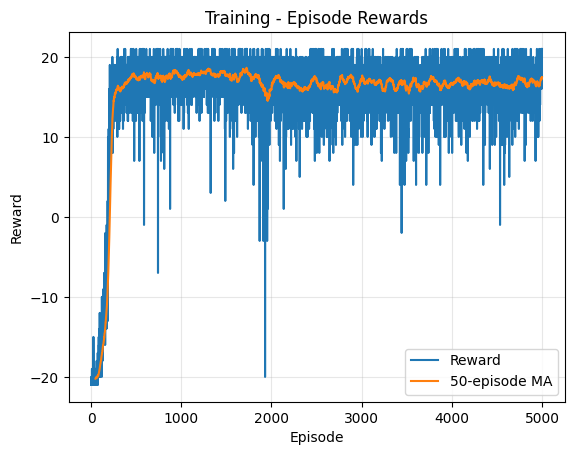

Complete


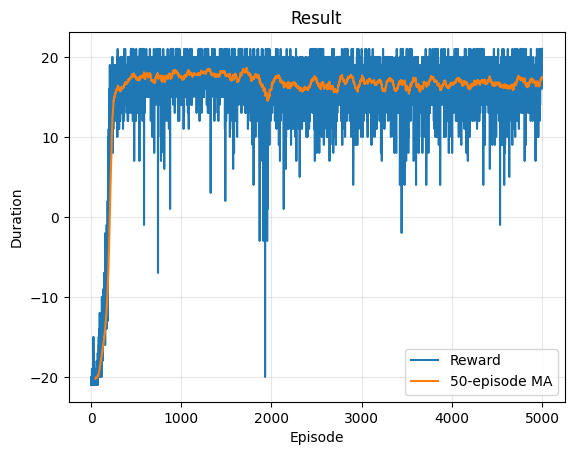

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
# Set up environment
env = gym.make("ALE/Pong-v5", render_mode=None, frameskip = 1, repeat_action_probability = 0.0)

# Preprocess FIRST
env = AtariPreprocessing(env, grayscale_obs=True, scale_obs=False, frame_skip=4, screen_size=84)

# Stack frames AFTER preprocessing
env = FrameStackManual(env, 4)


num_actions = env.action_space.n  # number of actions from the gym action space
state, info = env.reset()         # number of state observations
num_observations = state.shape[-1]

# The Deep Q-learning algorithm with experience replay:

# Initializing memory
replay_memory = ReplayBuffer(capacity=100000)

# Initializing action-value function Q, weights are random by default
q = DQN(num_actions).to(device)

# Initializing target action-value function Q^ with the same weights
target = DQN(num_actions).to(device)
target.load_state_dict(q.state_dict())

# Define optimizer (Adam)
# with LR = 0.00025
optimizer = optim.Adam(q.parameters(), lr=0.0001)



for episode in range(NUM_EPISODES):
  # Initializing environment and getting the first state
  state, info = env.reset()
  # Convert state to tensor
  state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

  total_reward = 0

  # This is basically a while true loop but it keeps count of t -> durations.
  for t in count():

    # select action randomly or with best Q-value
    action = select_action(state)

    # execute chosen action in emulator
    observation, reward, terminated, truncated, _ = env.step(action.item())

    # set next state (convert observation to tensor)
    if terminated:
      next_state = None
    else:
      next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

    # (set done variable)
    done = terminated or truncated

    total_reward += reward

    # (reward as tensor)
    reward = torch.tensor([reward], device=device)

    # store transition to replay memory
    replay_memory.push(state, action, next_state, reward)

    # move to next state
    state = next_state

    # optimize Q-network
    if steps_taken % 4 == 0:
      optimize_model()

    # update target by update rate
    if steps_taken % TARGET_UPDATE == 0:
          target.load_state_dict(q.state_dict())

    # if game's done, plot and break loop
    if done:
      #episode_durations.append(t + 1)
      #plot_durations()
      episode_rewards.append(total_reward)
      plot_rewards()
      break

    # save the net every 100 episodes
  if episode % 100 == 0:
      torch.save(q.state_dict(), "/content/drive/MyDrive/pong_dqn.pth")
      #files.download(f"dqn_pong_ep{episode}.pth")
      print(f"Saved checkpoint at episode {episode}")

print('Complete')
plot_durations(show_result=True)

In [ ]:
# save model
torch.save(q.state_dict(), "pong_dqn.pth")

In [ ]:
torch.save(q.state_dict(), "/content/drive/MyDrive/pong_dqn.pth")

## ChatGPT generated code for recording an episode

In [ ]:
import gymnasium as gym
import torch
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
from base64 import b64encode
import os

# Import necessary wrappers and classes from previous cells
from gymnasium.wrappers import AtariPreprocessing
# FrameStackManual and DQN are defined in previous cells, so they should be available.

# 1. Create environment with video recording and correct preprocessing
# Start with a base environment that can render RGB frames for recording purposes.
base_env = gym.make("ALE/Pong-v5", render_mode="rgb_array", frameskip=1, repeat_action_probability=0.0)

# Apply preprocessing as done during training
preprocessed_env = AtariPreprocessing(base_env, grayscale_obs=True, scale_obs=False, frame_skip=4, screen_size=84)

# Apply frame stacking as done during training
stacked_env = FrameStackManual(preprocessed_env, 4)

# Wrap the *fully processed and stacked* environment with RecordVideo.
# This means the observations passed to the agent will be correctly formatted,
# and the video will record the rendered output of the stacked_env (which itself can still call base_env's render).
env = RecordVideo(
    stacked_env,
    video_folder="videos",
    name_prefix="dqn-pong",
    episode_trigger=lambda x: x == 0 # Record only the first episode
)

# 2. Reload your trained model
# Assuming 'q' and 'device' are already defined in the global scope from previous executed cells.
q.load_state_dict(torch.load("pong_dqn.pth", map_location=torch.device('cpu' if not torch.cuda.is_available() else 'cuda')))
q.eval() # Set model to evaluation mode

# 3. Let the agent play one episode
state, _ = env.reset() # 'state' will now be (4, 84, 84) due to preprocessing and stacking
done = False
total_reward = 0

while not done:
    # 'state' is already (channels, height, width), so convert to tensor and add batch dimension.
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) # Becomes (1, 4, 84, 84)
    with torch.no_grad():
        action = q(state_tensor).argmax(dim=1).item()

    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward

env.close()
print("Total reward:", total_reward)

# 4. Display the video in Colab
video_files = [f for f in os.listdir("videos") if f.endswith(".mp4")]
if video_files:
    # Sort to get the latest video if multiple are recorded
    video_files.sort(key=lambda x: os.path.getmtime(os.path.join("videos", x)), reverse=True)
    video_path = video_files[0]
    mp4 = open(f"videos/{video_path}", 'rb').read()
    print(f"Playing video: {video_path}")
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f'<video width="640" height="480" controls><source src="{data_url}" type="video/mp4"></video>'))
else:
    print("No video file found in 'videos' directory.")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Total reward: 21.0
Playing video: dqn-pong-episode-0.mp4
